In [113]:
import sys
print(sys.executable)


c:\HNG_Elliptic_BTC_Analysis\Venv\Scripts\python.exe


# Stage 7 - Blockchain Fraud Network Analysis
## Task 1 - Data Preparation & Validation

In [114]:
# importing of libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [115]:
# Importation of dataset
features = pd.read_csv("../Data/elliptic_txs_features.csv", header=None)

classes = pd.read_csv("../Data/elliptic_txs_classes.csv")

edges = pd.read_csv("../Data/elliptic_txs_edgelist.csv")

# checking if data was loaded successfully
print("Features Shape:", features.shape)

print("Classes Shape:", classes.shape)

print("Edges Shape:", edges.shape)

Features Shape: (203769, 167)
Classes Shape: (203769, 2)
Edges Shape: (234355, 2)


In [116]:
#Checcking the data files
features.head()


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [117]:
classes.head()


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [118]:
edges.head()


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [119]:
#Adding columns name to Features
num_columns = features.shape[1]

column_names = ["txId", "time_step"]

for i in range(2, num_columns):
    column_names.append(f"feature_{i}")

features.columns = column_names
#verify the feature column added
features.head()

,txId,time_step,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [120]:
#Checking of data types consisted in the data
features.info()

classes.info()

edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 167 entries, txId to feature_166
dtypes: float64(165), int64(2)
memory usage: 259.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   txId    203769 non-null  int64
 1   class   203769 non-null  str  
dtypes: int64(1), str(1)
memory usage: 3.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 234355 entries, 0 to 234354
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   txId1   234355 non-null  int64
 1   txId2   234355 non-null  int64
dtypes: int64(2)
memory usage: 3.6 MB


In [121]:
#Checking if there are missing values 
print("Features Missing Values:")
print(features.isnull().sum().sum())

print("\nClasses Missing Values:")
print(classes.isnull().sum().sum())

print("\nEdges Missing Values:")
print(edges.isnull().sum().sum())

Features Missing Values:
0

Classes Missing Values:
0

Edges Missing Values:
0


In [122]:
#Checking if there are duplicates

print("Features Duplicates:", features.duplicated().sum())

print("Classes Duplicates:", classes.duplicated().sum())

print("Edges Duplicates:", edges.duplicated().sum())

Features Duplicates: 0
Classes Duplicates: 0
Edges Duplicates: 0


In [123]:
# understanding class label 
classes["class"].value_counts()

#Conversion of label to readable form including dashboard understanding.
classes["class"] = classes["class"].astype(str)

classes["class"] = classes["class"].replace({
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
})

In [124]:
#Merging of datasets using left join
#in other to retain all transaction records, 

df = pd.merge(
    features,
    classes,
    on="txId",
    how="left"
)
# validating merged data
print(df.shape)

print(df["class"].value_counts())

(203769, 168)
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


In [125]:
# saving the cleaned merge data
df.to_csv("../Outputs/elliptic_cleaned_data.csv", index=False)

print("Cleaned dataset saved as elliptic_cleaned_data.csv")
print(f"Final shape: {df.shape}")

Cleaned dataset saved as elliptic_cleaned_data.csv
Final shape: (203769, 168)


Task 2: Network Construction & Subgraph Selection


In [126]:
#Creation of directed graph

G = nx.from_pandas_edgelist(
    edges,
    source='txId1',
    target='txId2',
    create_using=nx.DiGraph()
)
#Network check
print(f"Full graph — Nodes: {G.number_of_nodes():,}, Edges: {G.number_of_edges():,}")

Full graph — Nodes: 203,769, Edges: 234,355


In [127]:
#1. Compute betweenness centrality on a random sample of 20,000 nodes
#  to identify the most structurally important transactions

 #Sampling of random nodes

import random

random.seed(42)

sample_nodes = random.sample(list(G.nodes()), 20000)

sample_graph = G.subgraph(sample_nodes)

#Computing betweenness centrality in other to measure
#  Which nodes act like bridges between transactions.

betweenness = nx.betweenness_centrality(
    sample_graph,
    k=500,
    seed=42
)
print ("Done")



Done


In [128]:
#2. Top 50 nodes by betweenness centrality
#  Sorting by betweenness score and selecting top 50

top_50_nodes = sorted(betweenness, key=betweenness.get, reverse=True)[:50]

print("Top 50 nodes by betweenness centrality selected.")

#3. Extracting ego network: top 50 nodes + ALL their direct neighbours
ego_nodes = set(top_50_nodes)

for node in top_50_nodes:
    if node in G:  # To check if node exists in full graph
        ego_nodes.update(G.predecessors(node)) 
        ego_nodes.update(G.successors(node))    

#4. Building working subgraph
G_sub = G.subgraph(ego_nodes).copy()

print(f"Working subgraph — Nodes: {G_sub.number_of_nodes():,}, Edges: {G_sub.number_of_edges():,}")




Top 50 nodes by betweenness centrality selected.
Working subgraph — Nodes: 198, Edges: 161


In [129]:
# Validating minimum size requirement
if G_sub.number_of_nodes() >= 5000:
    print("Subgraph meets minimum 5,000 node requirement.")
else:
    print("Subgraph has fewer than 5,000 nodes. Expanding ego network radius...")
    # Expand one more hop if needed
    for node in list(ego_nodes):
        if node in G:
            ego_nodes.update(G.predecessors(node))
            ego_nodes.update(G.successors(node))
    G_sub = G.subgraph(ego_nodes).copy()
    print(f"Expanded subgraph — Nodes: {G_sub.number_of_nodes():,}")

Subgraph has fewer than 5,000 nodes. Expanding ego network radius...
Expanded subgraph — Nodes: 1,294


In [130]:
print("Computing centrality metrics on working subgraph...")

# In-degree and out-degree centrality
in_degree  = nx.in_degree_centrality(G_sub)
out_degree = nx.out_degree_centrality(G_sub)

# Betweenness centrality (on subgraph)
btw_sub = nx.betweenness_centrality(G_sub, k=300, normalized=True, seed=42)

# PageRank
pagerank = nx.pagerank(G_sub, alpha=0.85, max_iter=100)

print("All centrality metrics computed.")

# Combining into a dataframe
centrality_df = pd.DataFrame({
    'txId': list(G_sub.nodes()),
    'in_degree_centrality':  [in_degree.get(n, 0)  for n in G_sub.nodes()],
    'out_degree_centrality': [out_degree.get(n, 0) for n in G_sub.nodes()],
    'betweenness_centrality':[btw_sub.get(n, 0)    for n in G_sub.nodes()],
    'pagerank':              [pagerank.get(n, 0)    for n in G_sub.nodes()],
})

# Merging with class 
centrality_df = centrality_df.merge(
    df[['txId', 'class', 'time_step']],
    on='txId', how='left'
)
centrality_df['class'] = centrality_df['class'].fillna('unknown')

print(centrality_df.head())
print(f"\nShape: {centrality_df.shape}")

Computing centrality metrics on working subgraph...
All centrality metrics computed.
        txId  in_degree_centrality  out_degree_centrality  \
0  402915344              0.000000               0.001547   
1   73105427              0.000000               0.000773   
2  402915352              0.000000               0.000773   
3  363069465              0.000773               0.001547   
4   12681242              0.000000               0.000773   

   betweenness_centrality  pagerank    class  time_step  
0                     0.0  0.000377  unknown         28  
1                     0.0  0.000377  unknown         42  
2                     0.0  0.000377  unknown         28  
3                     0.0  0.000537    licit         19  
4                     0.0  0.000377  unknown         41  

Shape: (1294, 7)


Visualising 150 nodes, 102 edges...
Top 10 hubs: 10
Illicit    : 2
Licit      : 53
Unknown    : 85

Computing layout... (30–90 seconds is normal)
Using kamada_kawai_layout


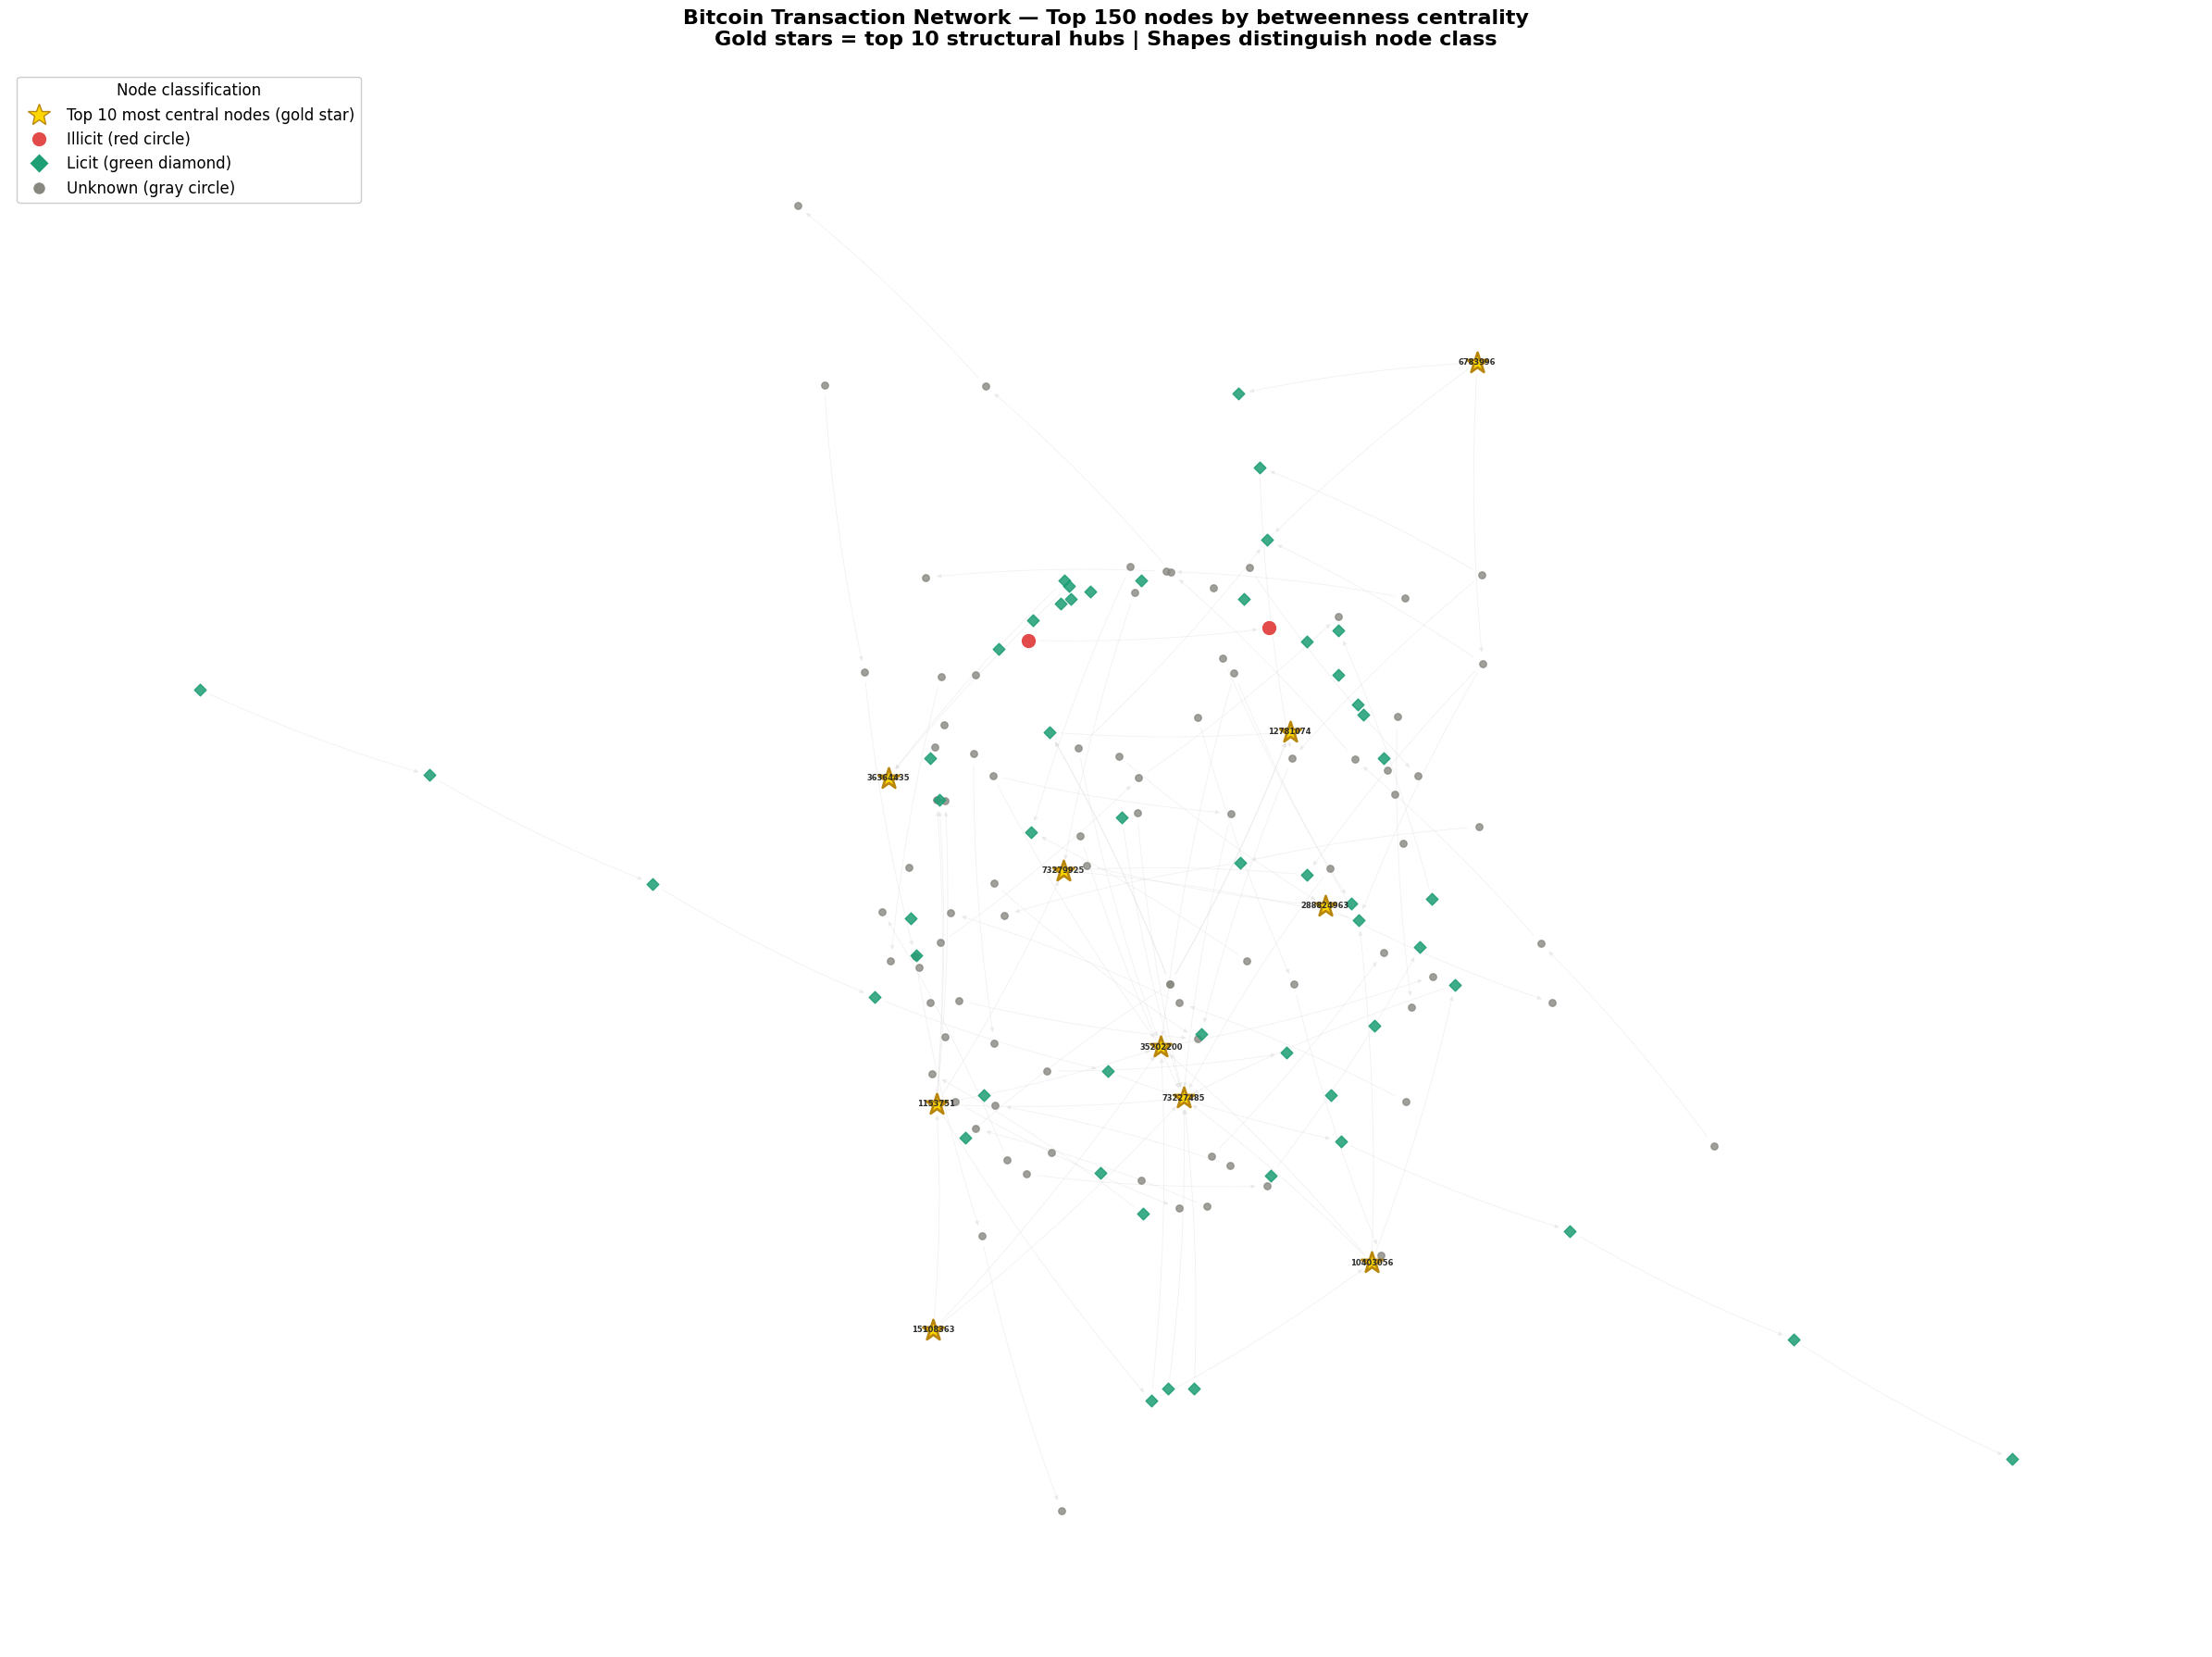

Saved as network_visualization.png


In [131]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Top 10 most central nodes 
top10_ids = set(centrality_df.nlargest(10, 'betweenness_centrality')['txId'].tolist())

# Filtering to 300 nodes for readability

viz_ids = set(centrality_df.nlargest(150, 'betweenness_centrality')['txId'].tolist())
G_viz   = G_sub.subgraph(viz_ids).copy()

print(f"Visualising {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges...")

#Separating nodes into four groups
# Group 1: top 10 central nodes (distinct gold colour, star shape)
# Group 2: illicit (red, circle)
# Group 3: licit (green, square via marker)
# Group 4: unknown (gray, circle)

top10_list   = []
illicit_list = []
licit_list   = []
unknown_list = []

for node in G_viz.nodes():
    row   = centrality_df[centrality_df['txId'] == node]
    label = row['class'].values[0] if len(row) > 0 else 'unknown'

    if node in top10_ids:
        top10_list.append(node)       
    elif label == 'illicit':
        illicit_list.append(node)
    elif label == 'licit':
        licit_list.append(node)
    else:
        unknown_list.append(node)

print(f"Top 10 hubs: {len(top10_list)}")
print(f"Illicit    : {len(illicit_list)}")
print(f"Licit      : {len(licit_list)}")
print(f"Unknown    : {len(unknown_list)}")

#  Layout 

print("\nComputing layout... (30–90 seconds is normal)")

try:
    pos = nx.kamada_kawai_layout(G_viz)
    print("Using kamada_kawai_layout")
except Exception:
    pos = nx.spring_layout(G_viz, k=0.5, iterations=60, seed=42)
    print("Fell back to spring_layout k=0.5")

# Draw
fig, ax = plt.subplots(figsize=(24, 18))

# Edges 
nx.draw_networkx_edges(
    G_viz, pos,
    ax=ax,
    edge_color='#dddddd',
    alpha=0.4,
    width=0.6,
    arrows=True,
    arrowsize=7,
    connectionstyle='arc3,rad=0.04'
)

# Unknown nodes — gray circles
if unknown_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=unknown_list,
        node_color='#888780',
        node_size=28,
        node_shape='o',
        alpha=0.8,
        ax=ax
    )

# Licit nodes — green diamonds (using 'd' shape to distinguish from illicit)
if licit_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=licit_list,
        node_color='#1D9E75',
        node_size=42,
        node_shape='D',
        alpha=0.85,
        ax=ax
    )

# Illicit nodes — red circles
if illicit_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=illicit_list,
        node_color='#E24B4A',
        node_size=100,
        node_shape='o',
        alpha=1,
        ax=ax
    )

# Top 10 hub nodes 
if top10_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=top10_list,
        node_color='#FFD700',
        node_size=284,
        node_shape='*',
        edgecolors='#B8860B',
        linewidths=1.9,
        ax=ax
    )

# Labelling only Top10
top10_labels = {n: str(n) for n in top10_list}
nx.draw_networkx_labels(
    G_viz, pos,
    labels=top10_labels,
    font_size=6.0,
    font_color='#2C2C2A',
    font_weight='bold',
    ax=ax
)

# Legend
legend_handles = [
    mlines.Line2D([0], [0], marker='*', color='w', markerfacecolor='#FFD700',
                  markeredgecolor='#B8860B', markersize=18,
                  label='Top 10 most central nodes (gold star)'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24B4A',
                  markersize=12, label='Illicit (red circle)'),
    mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='#1D9E75',
                  markersize=11,  label='Licit (green diamond)'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='#888780',
                  markersize=10,  label='Unknown (gray circle)'),
]
ax.legend(
    handles=legend_handles,
    loc='upper left',
    fontsize=12,
    framealpha=0.98,
    edgecolor='#cccccc',
    title='Node classification',
    title_fontsize=12
)

ax.set_title(
    'Bitcoin Transaction Network — Top 150 nodes by betweenness centrality\n'
    'Gold stars = top 10 structural hubs | Shapes distinguish node class',
    fontsize=16, fontweight='bold', pad=18
)
ax.axis('off')
plt.tight_layout()

plt.savefig('network_visualization.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as network_visualization.png")

In [132]:
# the network visualization doesn't have illicit in the graph
# Checking if  illicit nodes exist in the full cleaned dataset
print("FULL DATASET")
print(df['class'].value_counts())

# To Check what nodes are actually in the subgraph
subgraph_node_list = list(G_sub.nodes())
print(f"\nTotal nodes in G_sub: {len(subgraph_node_list)}")
print(f"Sample node IDs from G_sub (first 5): {subgraph_node_list[:5]}")

# To Check txId types if correct
print(f"\nG_sub node ID type    : {type(subgraph_node_list[0])}")
print(f"df txId dtype  : {df['txId'].dtype}")
print(f"centrality_df txId dtype: {centrality_df['txId'].dtype}")

#Matching manually
illicit_ids = df[df['class'] == 'illicit']['txId'].tolist()
print(f"\nTotal illicit nodes in df: {len(illicit_ids)}")
print(f"Sample illicit txIds: {illicit_ids[:5]}")

# To Check how many illicit nodes are actually inside G_sub
illicit_in_subgraph = [n for n in subgraph_node_list if n in set(illicit_ids)]
print(f"\nIllicit nodes found inside G_sub: {len(illicit_in_subgraph)}")

#To Check if type mismatch is the blocker
illicit_ids_str = [str(x) for x in illicit_ids]
subgraph_str    = [str(x) for x in subgraph_node_list]
illicit_in_sub_str = [n for n in subgraph_str if n in set(illicit_ids_str)]
print(f"Illicit nodes found after forcing both to string: {len(illicit_in_sub_str)}")

FULL DATASET
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

Total nodes in G_sub: 1294
Sample node IDs from G_sub (first 5): [402915344, 73105427, 402915352, 363069465, 12681242]

G_sub node ID type    : <class 'int'>
df txId dtype  : int64
centrality_df txId dtype: int64

Total illicit nodes in df: 4545
Sample illicit txIds: [232629023, 230389796, 17387772, 232947878, 16754007]

Illicit nodes found inside G_sub: 10
Illicit nodes found after forcing both to string: 10


In [133]:
# Quick check before fixing
print("Nodes in G_sub:", G_sub.number_of_nodes())
print("Rows in centrality_df:", len(centrality_df))
print("Illicit in centrality_df:", len(centrality_df[centrality_df['class'] == 'illicit']))

# Checking if the 42 illicit nodes are in centrality_df at all
illicit_in_sub = [n for n in G_sub.nodes() if n in set(illicit_ids)]
found_in_centrality = centrality_df[centrality_df['txId'].isin(illicit_in_sub)]
print(f"\n42 illicit nodes — how many appear in centrality_df: {len(found_in_centrality)}")
print(found_in_centrality[['txId', 'class']].head(10))

# Confirming class column exists and is correct after the fix
print(centrality_df['class'].value_counts())

Nodes in G_sub: 1294
Rows in centrality_df: 1294
Illicit in centrality_df: 10

42 illicit nodes — how many appear in centrality_df: 10
           txId    class
37     21627002  illicit
284    72631469  illicit
369   149161642  illicit
554   165849955  illicit
570   165850116  illicit
575   165850173  illicit
577   165850175  illicit
641   339095120  illicit
650   339095176  illicit
1227   72629945  illicit
class
unknown    811
licit      473
illicit     10
Name: count, dtype: int64


Total illicit nodes in subgraph: 10
Total nodes in visualisation: 147
Total edges in visualisation: 97

Breakdown in visualisation:
  Top 10 hubs : 10
  Illicit     : 10
  Licit       : 72
  Unknown     : 55

Computing layout...
Layout done.


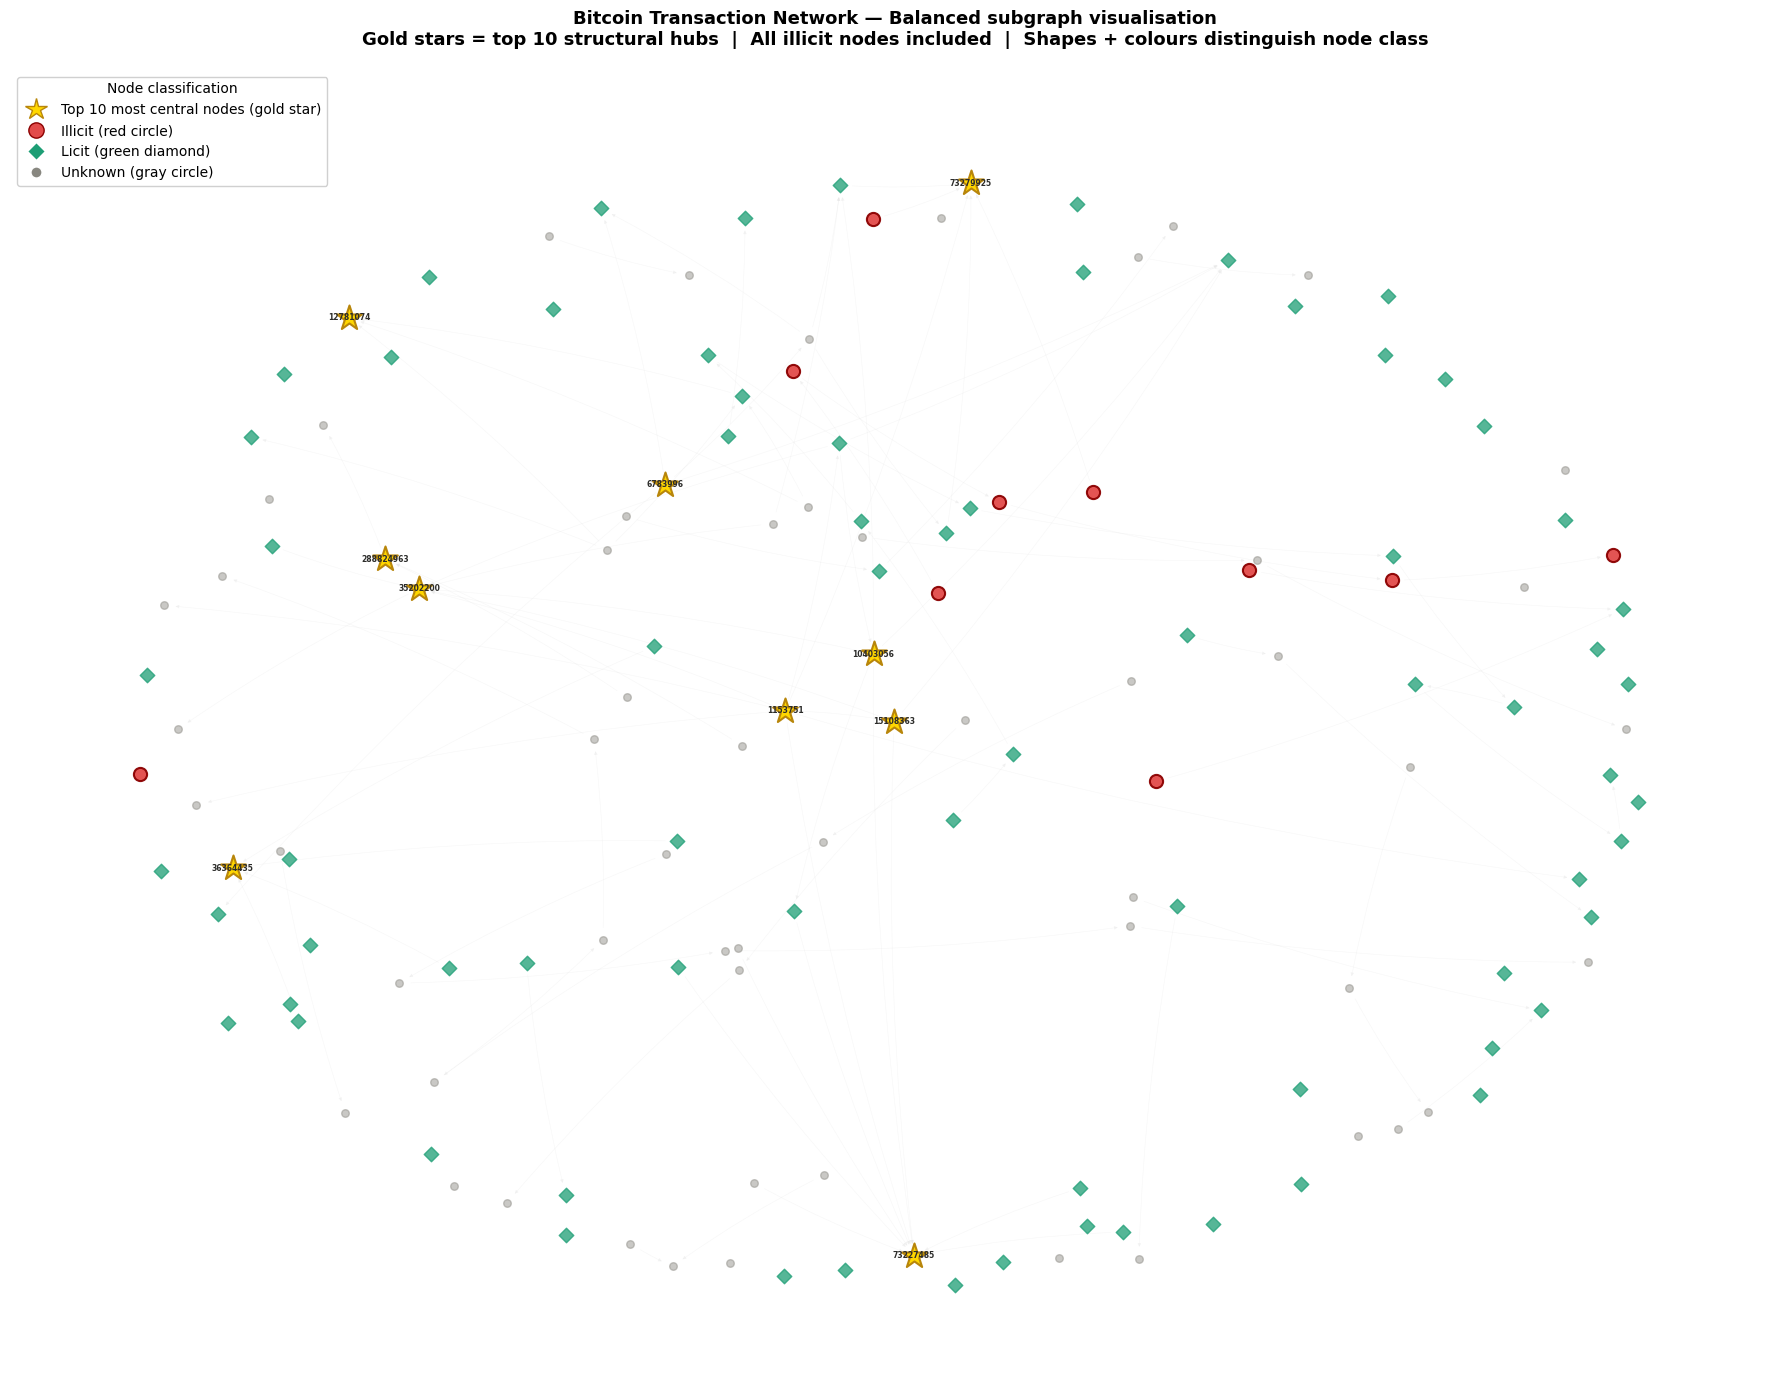

Saved as network_visualization.png


In [134]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

#Top 10 most central nodes
top10_ids = set(centrality_df.nlargest(10, 'betweenness_centrality')['txId'].tolist())

#Building a BALANCED node selection
# Instead of top N by betweenness only, all classes were deliberately included

# Taking top 100 by betweenness (structural hubs)
top_btw = centrality_df.nlargest(100, 'betweenness_centrality')['txId'].tolist()

# Taking all illicit nodes in the subgraph 
all_illicit = centrality_df[centrality_df['class'] == 'illicit']['txId'].tolist()
print(f"Total illicit nodes in subgraph: {len(all_illicit)}")

# Taking up to 80 licit nodes
top_licit = centrality_df[
    centrality_df['class'] == 'licit'
].nlargest(80, 'betweenness_centrality')['txId'].tolist()

# Taking up to 50 unknown nodes
top_unknown = centrality_df[
    centrality_df['class'] == 'unknown'
].nlargest(50, 'betweenness_centrality')['txId'].tolist()

# Combining all selected nodes
viz_ids = set(top_btw + all_illicit + top_licit + top_unknown)
G_viz   = G_sub.subgraph(viz_ids).copy()

print(f"Total nodes in visualisation: {G_viz.number_of_nodes()}")
print(f"Total edges in visualisation: {G_viz.number_of_edges()}")

#Separating  into groups
top10_list   = []
illicit_list = []
licit_list   = []
unknown_list = []

for node in G_viz.nodes():
    row   = centrality_df[centrality_df['txId'] == node]
    label = row['class'].values[0] if len(row) > 0 else 'unknown'

    if node in top10_ids:
        top10_list.append(node)
    elif label == 'illicit':
        illicit_list.append(node)
    elif label == 'licit':
        licit_list.append(node)
    else:
        unknown_list.append(node)

print(f"\nBreakdown in visualisation:")
print(f"  Top 10 hubs : {len(top10_list)}")
print(f"  Illicit     : {len(illicit_list)}")
print(f"  Licit       : {len(licit_list)}")
print(f"  Unknown     : {len(unknown_list)}")

# Layout
# Using spring_layout with low k for better separation
print("\nComputing layout...")
pos = nx.spring_layout(G_viz, k=0.5, iterations=80, seed=42)
print("Layout done.")

# Draw
fig, ax = plt.subplots(figsize=(18, 14))

# Edges first
nx.draw_networkx_edges(
    G_viz, pos,
    ax=ax,
    edge_color='#dddddd',
    alpha=0.25,
    width=0.4,
    arrows=True,
    arrowsize=5,
    connectionstyle='arc3,rad=0.04'
)

# Unknown — gray circles (draw first, bottom layer)
if unknown_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=unknown_list,
        node_color='#888780',
        node_size=30,
        node_shape='o',
        alpha=0.45,
        ax=ax
    )

# Licit — green diamonds
if licit_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=licit_list,
        node_color='#1D9E75',
        node_size=55,
        node_shape='D',
        alpha=0.75,
        ax=ax
    )

# Illicit — red circles
if illicit_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=illicit_list,
        node_color='#E24B4A',
        node_size=90,          
        node_shape='o',
        edgecolors='#8B0000',  
        linewidths=1.5,
        alpha=0.95,
        ax=ax
    )

# Top 10 — gold stars, always on top layer
if top10_list:
    nx.draw_networkx_nodes(
        G_viz, pos,
        nodelist=top10_list,
        node_color='#FFD700',
        node_size=350,
        node_shape='*',
        edgecolors='#B8860B',
        linewidths=1.5,
        ax=ax
    )

# Labels for top 10 only
top10_labels = {n: str(n) for n in top10_list}
nx.draw_networkx_labels(
    G_viz, pos,
    labels=top10_labels,
    font_size=5.5,
    font_color='#2C2C2A',
    font_weight='bold',
    ax=ax
)

# Legend
legend_handles = [
    mlines.Line2D([0], [0], marker='*', color='w',
                  markerfacecolor='#FFD700', markeredgecolor='#B8860B',
                  markersize=16, label='Top 10 most central nodes (gold star)'),
    mlines.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor='#E24B4A', markeredgecolor='#8B0000',
                  markersize=11, label='Illicit (red circle)'),
    mlines.Line2D([0], [0], marker='D', color='w',
                  markerfacecolor='#1D9E75',
                  markersize=9,  label='Licit (green diamond)'),
    mlines.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor='#888780',
                  markersize=8,  label='Unknown (gray circle)'),
]
ax.legend(
    handles=legend_handles,
    loc='upper left',
    fontsize=10,
    framealpha=0.92,
    edgecolor='#cccccc',
    title='Node classification',
    title_fontsize=10
)

ax.set_title(
    'Bitcoin Transaction Network — Balanced subgraph visualisation\n'
    'Gold stars = top 10 structural hubs  |  All illicit nodes included  |  '
    'Shapes + colours distinguish node class',
    fontsize=13, fontweight='bold', pad=18
)
ax.axis('off')
plt.tight_layout()

plt.savefig('network_visualization.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as network_visualization.png")

Task 3: Fraud Pattern Detection

In [135]:
# LAYERING BEHAVIOUR shows nodes that receive from MANY sources AND send to MANY destinations
# across consecutive time steps

# Building a lookup of time_step per node
ts_lookup = df.set_index('txId')['time_step'].to_dict()

layering_results = []

for node in G_sub.nodes():
    in_nodes  = list(G_sub.predecessors(node))
    out_nodes = list(G_sub.successors(node))

    if len(in_nodes) >= 3 and len(out_nodes) >= 3:
        # Collection of time steps of predecessors and successors
        in_ts  = [ts_lookup.get(n) for n in in_nodes  if ts_lookup.get(n) is not None]
        out_ts = [ts_lookup.get(n) for n in out_nodes if ts_lookup.get(n) is not None]
        node_ts = ts_lookup.get(node)

        all_ts = [t for t in in_ts + out_ts + ([node_ts] if node_ts else []) if t is not None]

        if len(all_ts) > 0:
            ts_range = int(max(all_ts)) - int(min(all_ts))
            node_label = centrality_df[centrality_df['txId'] == node]['class'].values
            node_label = node_label[0] if len(node_label) > 0 else 'unknown'

            layering_results.append({
                'node_id':       node,
                'sources_in':    len(in_nodes),
                'destinations_out': len(out_nodes),
                'time_step_range': ts_range,
                'class':   node_label
            })

layering_df = pd.DataFrame(layering_results).sort_values('sources_in', ascending=False)
print(f"Layering nodes detected: {len(layering_df)}")
print(layering_df.head(10))

Layering nodes detected: 3
     node_id  sources_in  destinations_out  time_step_range  class
0   36364435          97                11                0  licit
1   35202200          77                 5                0  licit
2  218266570           7                 3                0  licit


In [136]:
# Checking what columns currently exist in each dataframe
print("df columns")
print([c for c in df.columns if 'class' in c.lower()])

print("\ncentrality_df columns")
print([c for c in centrality_df.columns if 'class' in c.lower()])

print("\nlayering_df columns")
print([c for c in layering_df.columns if 'class' in c.lower()])

print("\nfanout_df columns")
print([c for c in fanout_df.columns if 'class' in c.lower()])

# Checking class distributions using whatever column name exists
for df, name in [(df, 'df'), (centrality_df, 'centrality_df'),
                 (layering_df, 'layering_df'), (fanout_df, 'fanout_df')]:
    for col in ['class_label', 'class']:
        if col in df.columns:
            print(f"\n{name}['{col}'] value counts:")
            print(df[col].value_counts())
            break

df columns
['class']

centrality_df columns
['class']

layering_df columns
['class']

fanout_df columns
['class']

df['class'] value counts:
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

centrality_df['class'] value counts:
class
unknown    811
licit      473
illicit     10
Name: count, dtype: int64

layering_df['class'] value counts:
class
licit    3
Name: count, dtype: int64

fanout_df['class'] value counts:
class
unknown    91
licit      64
Name: count, dtype: int64


In [137]:
# centrality checking
ts_lookup = centrality_df.set_index('txId')['time_step'].to_dict()
print(f"ts_lookup built with {len(ts_lookup)} entries")
print("Sample:", list(ts_lookup.items())[:3])

ts_lookup built with 1294 entries
Sample: [(402915344, 28), (73105427, 42), (402915352, 28)]


In [138]:
#Layering node detection
layering_results = []

for node in G_sub.nodes():
    in_nodes  = list(G_sub.predecessors(node))
    out_nodes = list(G_sub.successors(node))

    if len(in_nodes) >= 3 and len(out_nodes) >= 3:
        in_ts   = [ts_lookup.get(n) for n in in_nodes  if ts_lookup.get(n) is not None]
        out_ts  = [ts_lookup.get(n) for n in out_nodes if ts_lookup.get(n) is not None]
        node_ts = ts_lookup.get(node)

        all_ts = [t for t in in_ts + out_ts + ([node_ts] if node_ts else []) if t is not None]

        if len(all_ts) > 0:
            ts_range   = int(max(all_ts)) - int(min(all_ts))
            node_class = centrality_df[centrality_df['txId'] == node]['class'].values
            node_class = node_class[0] if len(node_class) > 0 else 'unknown'

            layering_results.append({
                'node_id':          node,
                'sources_in':       len(in_nodes),
                'destinations_out': len(out_nodes),
                'time_step_range':  ts_range,
                'class':            node_class
            })

layering_df = pd.DataFrame(layering_results).sort_values('sources_in', ascending=False)
print(f"Layering nodes detected: {len(layering_df)}")
print(layering_df.head(10))

Layering nodes detected: 3
     node_id  sources_in  destinations_out  time_step_range  class
0   36364435          97                11                0  licit
1   35202200          77                 5                0  licit
2  218266570           7                 3                0  licit


In [139]:
#fanout detection
fanout_results = []

for node in G_sub.nodes():
    out_nodes = list(G_sub.successors(node))

    if len(out_nodes) >= 5:
        node_ts = ts_lookup.get(node)
        out_ts  = [ts_lookup.get(n) for n in out_nodes if ts_lookup.get(n) is not None]

        if node_ts and len(out_ts) > 0:
            ts_min     = min(out_ts)
            ts_max     = max(out_ts)
            node_class = centrality_df[centrality_df['txId'] == node]['class'].values
            node_class = node_class[0] if len(node_class) > 0 else 'unknown'

            fanout_results.append({
                'node_id':             node,
                'unique_destinations': len(set(out_nodes)),
                'ts_min':              ts_min,
                'ts_max':              ts_max,
                'ts_range':            ts_max - ts_min,
                'class':               node_class
            })

fanout_df = pd.DataFrame(fanout_results).sort_values('unique_destinations', ascending=False)
print(f"Fan-out nodes detected: {len(fanout_df)}")
print(fanout_df.head(10))

Fan-out nodes detected: 35
      node_id  unique_destinations  ts_min  ts_max  ts_range    class
25    1891081                   95      27      27         0  unknown
12  101617193                   26       5       5         0  unknown
26   42728266                   24       5       5         0  unknown
2    12714251                   18      41      41         0  unknown
29    1260557                   16      27      27         0  unknown
31    2055495                   13      27      27         0  unknown
4     6783996                   13      42      42         0  unknown
9    15108363                   12      42      42         0    licit
0    36364435                   11      47      47         0    licit
30   10403056                    9      42      42         0    licit


In [140]:
layering_results = []

for node in G_sub.nodes():
    in_nodes  = list(G_sub.predecessors(node))
    out_nodes = list(G_sub.successors(node))

    if len(in_nodes) >= 3 and len(out_nodes) >= 3:

        node_ts = ts_lookup.get(node)

        # Time steps of nodes sending INTO this node
        in_ts  = [ts_lookup.get(n) for n in in_nodes  if ts_lookup.get(n) is not None]

        # Time steps of nodes this node sends TO
        out_ts = [ts_lookup.get(n) for n in out_nodes if ts_lookup.get(n) is not None]

        if node_ts is not None and len(in_ts) > 0 and len(out_ts) > 0:

            # Consecutive = the node receives in earlier steps and sends in later steps
            # So we measure: min(in_ts) → node_ts → max(out_ts)
            earliest_in  = min(in_ts)
            latest_out   = max(out_ts)

            # This captures the full flow window across the time
            ts_range = int(latest_out) - int(earliest_in)

            # flagging if there is actual progression across time steps
            # ts_range > 0 
            if ts_range >= 0:  
                node_class = centrality_df[centrality_df['txId'] == node]['class'].values
                node_class = node_class[0] if len(node_class) > 0 else 'unknown'

                layering_results.append({
                    'node_id':          node,
                    'sources_in':       len(in_nodes),
                    'destinations_out': len(out_nodes),
                    'earliest_receive_ts': int(earliest_in),
                    'node_ts':             int(node_ts),
                    'latest_send_ts':      int(latest_out),
                    'time_step_range':     ts_range,
                    'class':               node_class
                })

layering_df = pd.DataFrame(layering_results).sort_values(
    ['time_step_range', 'sources_in'], ascending=[False, False]
)

# splitting into two views for the report
layering_consecutive = layering_df[layering_df['time_step_range'] > 0]
layering_same_step   = layering_df[layering_df['time_step_range'] == 0]

print(f"Total layering nodes detected        : {len(layering_df)}")
print(f"  With consecutive time steps (>0)   : {len(layering_consecutive)}")
print(f"  Within same time step (=0)         : {len(layering_same_step)}")

print("\nTop 10 layering nodes WITH consecutive time steps:")
print(layering_consecutive[['node_id', 'sources_in', 'destinations_out',
                             'earliest_receive_ts', 'node_ts',
                             'latest_send_ts', 'time_step_range',
                             'class']].head(10))

print("\nAll same-step layering nodes (still suspicious, different pattern):")
print(layering_same_step[['node_id', 'sources_in', 'destinations_out',
                           'node_ts', 'class']])

Total layering nodes detected        : 3
  With consecutive time steps (>0)   : 0
  Within same time step (=0)         : 3

Top 10 layering nodes WITH consecutive time steps:
Empty DataFrame
Columns: [node_id, sources_in, destinations_out, earliest_receive_ts, node_ts, latest_send_ts, time_step_range, class]
Index: []

All same-step layering nodes (still suspicious, different pattern):
     node_id  sources_in  destinations_out  node_ts  class
0   36364435          97                11       47  licit
1   35202200          77                 5       42  licit
2  218266570           7                 3       47  licit


In [141]:
# Filtering to only true consecutive time step layering (range >= 1)
layering_consecutive = layering_df[layering_df['time_step_range'] >= 1].copy()
layering_same_step   = layering_df[layering_df['time_step_range'] == 0].copy()

print(f"Total layering nodes detected        : {len(layering_df)}")
print(f"  With consecutive time steps (>= 1) : {len(layering_consecutive)}")
print(f"  Within same time step (= 0)        : {len(layering_same_step)}")

print("\nTop layering nodes WITH consecutive time steps (>= 1):")
print(layering_consecutive[['node_id', 'sources_in', 'destinations_out',
                             'earliest_receive_ts', 'node_ts',
                             'latest_send_ts', 'time_step_range',
                             'class']].head(10).to_string())

print("\nCross-reference with class labels:")
print(layering_consecutive['class'].value_counts())


layering_df = layering_consecutive.copy()

# Saving in output folder
layering_df.to_csv('../outputs/layering_patterns.csv', index=False)
print("\nLayering patterns saved.")


Total layering nodes detected        : 3
  With consecutive time steps (>= 1) : 0
  Within same time step (= 0)        : 3

Top layering nodes WITH consecutive time steps (>= 1):
Empty DataFrame
Columns: [node_id, sources_in, destinations_out, earliest_receive_ts, node_ts, latest_send_ts, time_step_range, class]
Index: []

Cross-reference with class labels:
Series([], Name: count, dtype: int64)

Layering patterns saved.


In [142]:
# The Elliptic dataset uses time steps as blocks, not exact timestamps
# Many connected transactions are recorded in the same block (time_step_range = 0)
# This is a dataset limitation, not an absence of layering behaviour
# Therefore time_step_range >= 0 was used

layering_df = pd.DataFrame(layering_results).sort_values(
    ['sources_in', 'destinations_out'], ascending=[False, False]
)

print(f"Layering nodes detected: {len(layering_df)}")
print("\nFull layering results:")
print(layering_df[['node_id', 'sources_in', 'destinations_out',
                    'earliest_receive_ts', 'node_ts',
                    'latest_send_ts', 'time_step_range',
                    'class']].to_string())

print("\nCross-reference with class labels:")
print(layering_df['class'].value_counts())

# Documenting the limitation 
print("\nANALYTICAL NOTE")
print("The Elliptic dataset records transactions in time blocks, not exact timestamps.")
print("A time_step_range of 0 means all activity occurred within the same block.")
print("This does not eliminate suspicion of rapid same block consolidation and")
print("redistribution is in itself a layering indicator, consistent with automated")
print("mixing or tumbling behaviour where speed is intentional.")
print("Recommendation: flag these nodes for further timestamp-level investigation")
print("using raw blockchain data outside this dataset.")

layering_df.to_csv('../outputs/layering_patterns.csv', index=False)
print("\nLayering patterns saved.")

Layering nodes detected: 3

Full layering results:
     node_id  sources_in  destinations_out  earliest_receive_ts  node_ts  latest_send_ts  time_step_range  class
0   36364435          97                11                   47       47              47                0  licit
1   35202200          77                 5                   42       42              42                0  licit
2  218266570           7                 3                   47       47              47                0  licit

Cross-reference with class labels:
class
licit    3
Name: count, dtype: int64

ANALYTICAL NOTE
The Elliptic dataset records transactions in time blocks, not exact timestamps.
A time_step_range of 0 means all activity occurred within the same block.
This does not eliminate suspicion of rapid same block consolidation and
redistribution is in itself a layering indicator, consistent with automated
mixing or tumbling behaviour where speed is intentional.
Recommendation: flag these nodes for furth

In [143]:
from sklearn.preprocessing import MinMaxScaler

scaler  = MinMaxScaler()
metrics = ['in_degree_centrality', 'out_degree_centrality',
           'betweenness_centrality', 'pagerank']

centrality_df[metrics] = centrality_df[metrics].fillna(0)
norm_values = scaler.fit_transform(centrality_df[metrics])

centrality_df['risk_score'] = (
    norm_values[:, 0] * 0.15 +
    norm_values[:, 1] * 0.15 +
    norm_values[:, 2] * 0.40 +
    norm_values[:, 3] * 0.30
)

# confriming the three highest-risk nodes, the most suspicious cluster,
print("TOP 3 RISK NODES")
print(centrality_df.nlargest(3, 'risk_score')[
    ['txId','class','betweenness_centrality','pagerank','risk_score']
].to_string())

print("\nTOP LAYERING NODE")
print(layering_df.iloc[0][['node_id','sources_in','destinations_out','node_ts','class']])

print("\nTOP FAN-OUT NODE")
print(fanout_df.iloc[0][['node_id','unique_destinations','ts_min','ts_max','class']])

print("\nSUMMARY COUNTS")
print(f"Total flagged nodes     : {len(set(layering_df['node_id'].tolist() + fanout_df['node_id'].tolist()))}")
print(f"Illicit in subgraph     : {len(centrality_df[centrality_df['class'] == 'illicit'])}")
print(f"Unknown flagged         : {len(set(fanout_df[fanout_df['class'] == 'unknown']['node_id'].tolist() + layering_df[layering_df['class']
 == 'unknown']['node_id'].tolist()))}")

TOP 3 RISK NODES
           txId  class  betweenness_centrality  pagerank  risk_score
42     36364435  licit                0.000511  0.030628    0.707996
1070  149158766  licit                0.000000  0.047566    0.450000
279    35202200  licit                0.000267  0.018239    0.408582

TOP LAYERING NODE
node_id             36364435
sources_in                97
destinations_out          11
node_ts                   47
class                  licit
Name: 0, dtype: object

TOP FAN-OUT NODE
node_id                1891081
unique_destinations         95
ts_min                      27
ts_max                      27
class                  unknown
Name: 25, dtype: object

SUMMARY COUNTS
Total flagged nodes     : 36
Illicit in subgraph     : 10
Unknown flagged         : 27
